# Goal Analysis

Authoritative record of how goals are placed and how difficult each maze is
under the detour index used by the placement algorithm.

Source data: mazes in `mazes/txt/`. Goal placement is deterministic
(`src/goal_placement.py`); no run logs are needed for this analysis.

## Setup

Imports `src` modules (maze parsing, goal placement) and numpy/matplotlib/seaborn.

In [29]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.parser.maze_parser import parse_maze
from src.goal_placement import scenario_goals

MAZES_DIR = REPO_ROOT / "mazes" / "txt"
FIGURES_DIR = REPO_ROOT / "docs" / "res"
START = (0, 0)

# LaTeX-like (Computer Modern) look, matching the pandoc/LaTeX report font.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "axes.formatter.use_mathtext": True,
})

### Detour-index heatmap evolution (k = 1..4, fixed maze)

For a chosen maze, one heatmap per goal (k = 1..4) shows the score map
`place_goals` maximizes to pick that goal:
1. **goal 1** → detour from the start;
2. **goal k (k ≥ 2)** → cell-wise minimum of the detours from the start and
   from every goal already placed; its maximum is goal *k*.

Empty cells are not candidates (start or unreachable). Origin `(0,0)` is
**bottom-left**, labeled `S0`. Previously placed goals are marked `G` (light
green fill); the goal selected at the current step is outlined in a richer
green (no fill).

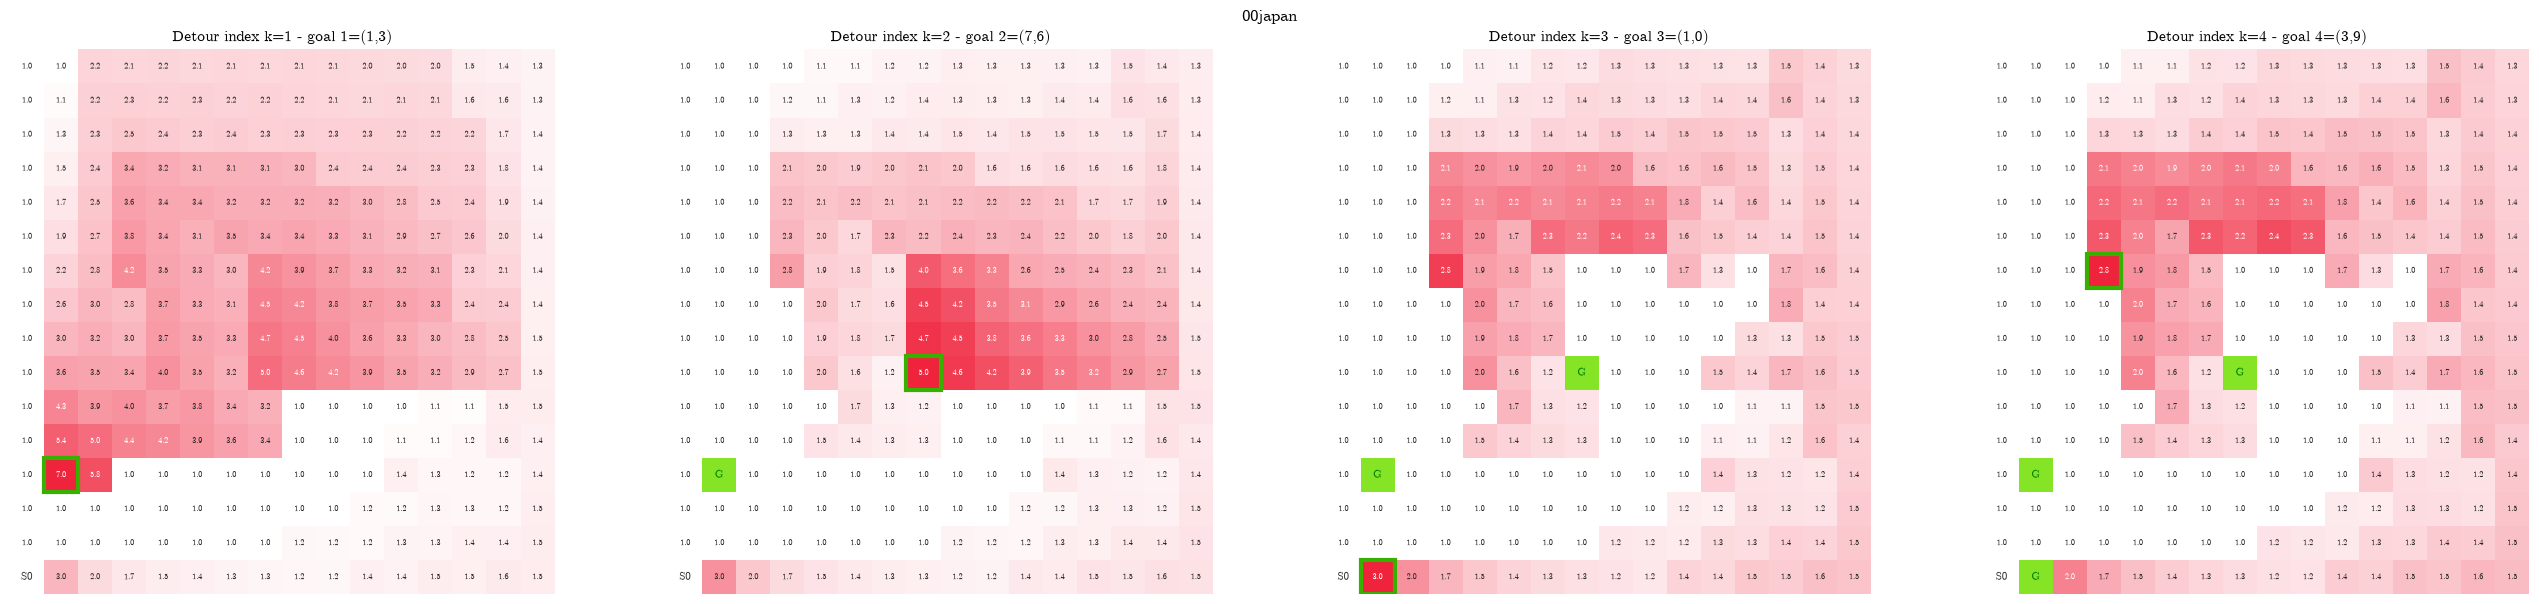

In [30]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

from src.goal_placement import (
    bfs_distance_map, detour_map, argmax_cell, _combine_min,
)

WHITE_RED = LinearSegmentedColormap.from_list("white_red", ["white", "#ef233c"])


def goal_score_panels(wall_matrix, width, height, start, k):
    """Score maps place_goals uses to pick each goal 1..k.

    Returns a list of (i, score_map, goal, prev_goals): at step i the
    score_map's argmax is `goal`; prev_goals are the goals chosen at
    previous steps (for context).
    """
    det_start = detour_map(bfs_distance_map(wall_matrix, width, height, start),
                           start, width, height)
    det_maps = [det_start]
    excluded = {start}
    chosen = []
    panels = []
    for i in range(1, k + 1):
        score_map = det_start if len(det_maps) == 1 else _combine_min(det_maps, width, height)
        goal, _ = argmax_cell(score_map, width, height, excluded) # type: ignore
        panels.append((i, score_map, goal, list(chosen)))
        excluded.add(goal)
        chosen.append(goal)
        det_maps.append(detour_map(bfs_distance_map(wall_matrix, width, height, goal),
                                   goal, width, height))
    return panels


def show_heatmap(ax, score_map, goal, prev_goals, start, title):
    """Heatmap of the score map: previous goals in light green (labeled G),
    current goal outlined in a richer green, start labeled S0. y=0 at bottom."""
    m = np.array(score_map, dtype=float)
    h, w = m.shape
    flip = m[::-1]                       # row 0 (y=0) at the bottom
    mask = np.isnan(flip)
    labels = np.where(mask, "", np.round(flip, 1).astype("U8"))
    sns.heatmap(flip, ax=ax, cmap=WHITE_RED, mask=mask,
                annot=labels, fmt="", annot_kws={"fontsize": 6},
                cbar=False,
                linewidths=.5, linecolor="#f2f2f200",
                square=True, xticklabels=False, yticklabels=False)
    for px, py in prev_goals:            # previously placed goals: light green fill + label
        ax.add_patch(Rectangle((px, h - 1 - py), 1, 1, fill=True,
                                   facecolor="#70e000", edgecolor="none",
                                   alpha=0.85, zorder=5))
        ax.text(px + 0.5, h - 1 - py + 0.5, "G", ha="center", va="center",
                fontsize=8, fontweight="bold", color="#008000", zorder=6)
    gx, gy = goal                        # goal chosen at this step: richer green outline only
    ax.add_patch(Rectangle((gx, h - 1 - gy), 1, 1, fill=False,
                               edgecolor="#38b000", lw=3, zorder=5))
    sx, sy = start                       # start cell: labeled S0
    ax.text(sx + 0.5, h - 1 - sy + 0.5, "S0", ha="center", va="center",
            fontsize=8, fontweight="bold", color="#333333", zorder=6)
    ax.set_title(title, fontsize=11)


# --- choose maze and how many goals to reconstruct (k >= 2) ---
MAZE = "00japan"
K = 4

wm, w, h = parse_maze(str(MAZES_DIR / f"{MAZE}.txt"))
panels = goal_score_panels(wm, w, h, START, K)

fig, axes = plt.subplots(1, len(panels),
                         figsize=(len(panels) * (0.32 * w + 1.5), 0.32 * h + 1))
for ax, (i, score_map, goal, prev_goals) in zip(axes.flat, panels):
    show_heatmap(ax, score_map, goal, prev_goals, START,
                 f"Detour index k={i} - goal {i}=({goal[0]},{goal[1]})")
fig.suptitle(MAZE)
fig.tight_layout()
plt.show()

In [31]:
fig.savefig(FIGURES_DIR / "goal_heatmap_evolution.svg", bbox_inches="tight")
print(f"saved: {FIGURES_DIR / 'goal_heatmap_evolution.svg'}")

saved: /Users/gofrancesco99/Desktop/GITHUB-prjs/Rob-26-MazeSolver/docs/res/goal_heatmap_evolution.svg


### Hardest mazes per scenario — detour index ranking

For each scenario (`k = 1..4` goals), mazes are ranked by the **difficulty of
the chosen goals**, measured by the detour index (`d_BFS / d_Manhattan`)
returned by `scenario_goals`.

The table is **sorted by mean detour** of the scenario's goals; `total_detour`
(sum) is shown alongside as a complementary measure — within a scenario every
maze has the same number of goals, so the sum is proportional to the mean and
never changes the ranking; it's kept only for readability.

> `n_goals < k` flags the rare mazes where placement runs out of candidate
> cells before k goals are placed.

In [32]:
import pandas as pd
from IPython.display import display

TOP_N = 5
K_MAX = 4
MAZE_FILES = sorted(MAZES_DIR.glob("*.txt"))


def scenario_detour_table(k):
    """One record per maze: mean and total detour of scenario k's goals."""
    rows = []
    for path in MAZE_FILES:
        wm, w, h = parse_maze(str(path))
        try:
            goals = scenario_goals(wm, w, h, START, k)
        except ValueError:
            continue                       # scenario not valid for this maze
        detours = [d for _, d in goals]
        if not detours:
            continue
        rows.append({
            "maze":          path.stem,
            "n_goals":       len(detours),
            "mean_detour":   float(np.mean(detours)),
            "total_detour":  float(np.sum(detours)),
        })
    df = pd.DataFrame(rows).sort_values("mean_detour", ascending=False)
    return df.reset_index(drop=True)


for k in range(1, K_MAX + 1):
    top = scenario_detour_table(k).head(TOP_N).copy()
    top.index = pd.RangeIndex(start=1, stop=len(top) + 1, step=1)
    print(f"\n=== Scenario k={k} — top {TOP_N} mazes by mean detour ===")
    display(top.round(3))


=== Scenario k=1 — top 5 mazes by mean detour ===


,maze,n_goals,mean_detour,total_detour
1,2013japan,1,63.000,63.000
2,j1,1,45.000,45.000
3,zigzag,1,35.667,35.667
4,2014japan,1,31.000,31.000
5,91japq,1,27.000,27.000



=== Scenario k=2 — top 5 mazes by mean detour ===


,maze,n_goals,mean_detour,total_detour
1,2013japan,2,33.154,66.308
2,zigzag,2,30.333,60.667
3,j1,2,25.200,50.400
4,2014japan,2,23.750,47.500
5,89sina1,2,21.333,42.667



=== Scenario k=3 — top 5 mazes by mean detour ===


,maze,n_goals,mean_detour,total_detour
1,zigzag,3,24.222,72.667
2,2013japan,3,22.969,68.908
3,j1,3,18.345,55.036
4,2014japan,3,17.389,52.167
5,89sina1,3,15.343,46.030



=== Scenario k=4 — top 5 mazes by mean detour ===


,maze,n_goals,mean_detour,total_detour
1,zigzag,4,19.250,77.000
2,2013japan,4,17.852,71.408
3,j1,4,14.592,58.370
4,2014japan,4,13.649,54.595
5,89sina1,4,12.258,49.030


#### Markdown export

Same top-5 tables per scenario, formatted for pasting into the report. Prints
the raw text (copyable) and shows a rendered preview.

In [33]:
from IPython.display import Markdown


def scenario_table_md(df, k, top_n=TOP_N):
    """Top-N mazes of scenario k as a Markdown table (one row per rank)."""
    top = df.head(top_n).reset_index(drop=True)
    lines = [
        f"#### Scenario k={k} — top {top_n} mazes by mean detour",
        "",
        "| # | maze | n_goals | mean detour | total detour |",
        "|--:|------|-------:|-------------:|--------------:|",
    ]
    for rank, r in enumerate(top.itertuples(index=False), start=1):
        lines.append(
            f"| {rank} | {r.maze} | {r.n_goals} | "
            f"{r.mean_detour:.3f} | {r.total_detour:.3f} |"
        )
    return "\n".join(lines)


md_report = "\n\n".join(
    scenario_table_md(scenario_detour_table(k), k) for k in range(1, K_MAX + 1)
)
print(md_report)                    # raw text, copyable into the report
display(Markdown(md_report))        # rendered preview

#### Scenario k=1 — top 5 mazes by mean detour

| # | maze | n_goals | mean detour | total detour |
|--:|------|-------:|-------------:|--------------:|
| 1 | 2013japan | 1 | 63.000 | 63.000 |
| 2 | j1 | 1 | 45.000 | 45.000 |
| 3 | zigzag | 1 | 35.667 | 35.667 |
| 4 | 2014japan | 1 | 31.000 | 31.000 |
| 5 | 91japq | 1 | 27.000 | 27.000 |

#### Scenario k=2 — top 5 mazes by mean detour

| # | maze | n_goals | mean detour | total detour |
|--:|------|-------:|-------------:|--------------:|
| 1 | 2013japan | 2 | 33.154 | 66.308 |
| 2 | zigzag | 2 | 30.333 | 60.667 |
| 3 | j1 | 2 | 25.200 | 50.400 |
| 4 | 2014japan | 2 | 23.750 | 47.500 |
| 5 | 89sina1 | 2 | 21.333 | 42.667 |

#### Scenario k=3 — top 5 mazes by mean detour

| # | maze | n_goals | mean detour | total detour |
|--:|------|-------:|-------------:|--------------:|
| 1 | zigzag | 3 | 24.222 | 72.667 |
| 2 | 2013japan | 3 | 22.969 | 68.908 |
| 3 | j1 | 3 | 18.345 | 55.036 |
| 4 | 2014japan | 3 | 17.389 | 52.167 |
| 5 | 89sina1 

#### Scenario k=1 — top 5 mazes by mean detour

| # | maze | n_goals | mean detour | total detour |
|--:|------|-------:|-------------:|--------------:|
| 1 | 2013japan | 1 | 63.000 | 63.000 |
| 2 | j1 | 1 | 45.000 | 45.000 |
| 3 | zigzag | 1 | 35.667 | 35.667 |
| 4 | 2014japan | 1 | 31.000 | 31.000 |
| 5 | 91japq | 1 | 27.000 | 27.000 |

#### Scenario k=2 — top 5 mazes by mean detour

| # | maze | n_goals | mean detour | total detour |
|--:|------|-------:|-------------:|--------------:|
| 1 | 2013japan | 2 | 33.154 | 66.308 |
| 2 | zigzag | 2 | 30.333 | 60.667 |
| 3 | j1 | 2 | 25.200 | 50.400 |
| 4 | 2014japan | 2 | 23.750 | 47.500 |
| 5 | 89sina1 | 2 | 21.333 | 42.667 |

#### Scenario k=3 — top 5 mazes by mean detour

| # | maze | n_goals | mean detour | total detour |
|--:|------|-------:|-------------:|--------------:|
| 1 | zigzag | 3 | 24.222 | 72.667 |
| 2 | 2013japan | 3 | 22.969 | 68.908 |
| 3 | j1 | 3 | 18.345 | 55.036 |
| 4 | 2014japan | 3 | 17.389 | 52.167 |
| 5 | 89sina1 | 3 | 15.343 | 46.030 |

#### Scenario k=4 — top 5 mazes by mean detour

| # | maze | n_goals | mean detour | total detour |
|--:|------|-------:|-------------:|--------------:|
| 1 | zigzag | 4 | 19.250 | 77.000 |
| 2 | 2013japan | 4 | 17.852 | 71.408 |
| 3 | j1 | 4 | 14.592 | 58.370 |
| 4 | 2014japan | 4 | 13.649 | 54.595 |
| 5 | 89sina1 | 4 | 12.258 | 49.030 |